<a href="https://colab.research.google.com/github/mdmasoomcse/TNS-prcatice-sessions/blob/main/Unsupervised_learning%20Evalution%20metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Evaluation Metrics for Unsupervised Learning

Unsupervised learning, particularly clustering, often lacks ground truth labels, making evaluation challenging. However, several internal validation metrics can help assess the quality of a clustering solution by examining the compactness of clusters and the separation between them. Here, we'll explore some common metrics with examples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

### 1. Elbow Method

The Elbow Method is a heuristic used to determine the optimal number of clusters (K) for K-Means clustering. It plots the within-cluster sum of squares (WCSS) against the number of clusters. The 'elbow' point on the graph, where the rate of decrease in WCSS sharply changes, is considered the optimal K.

#### Example 1: Synthetic Data

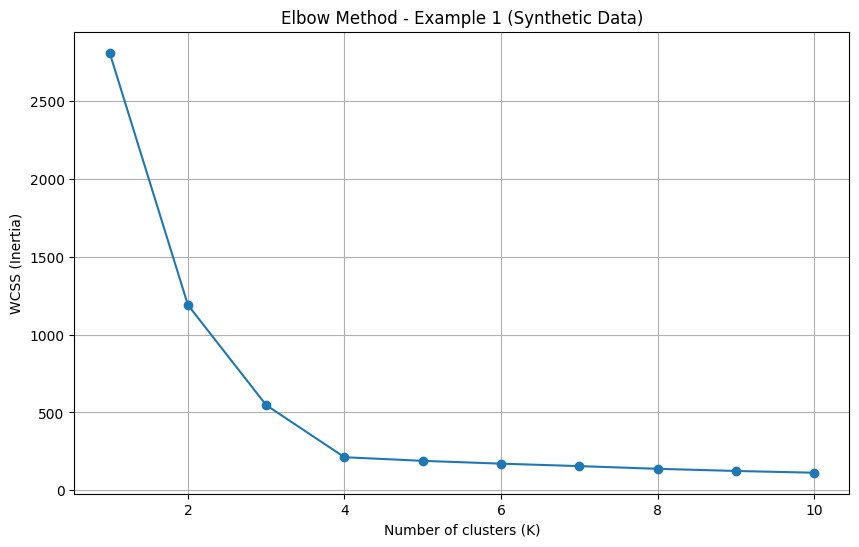

From the plot, the 'elbow' appears to be around K=4.


In [2]:
# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method - Example 1 (Synthetic Data)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()
print("From the plot, the 'elbow' appears to be around K=4.")

#### Example 2: Another Synthetic Data Set

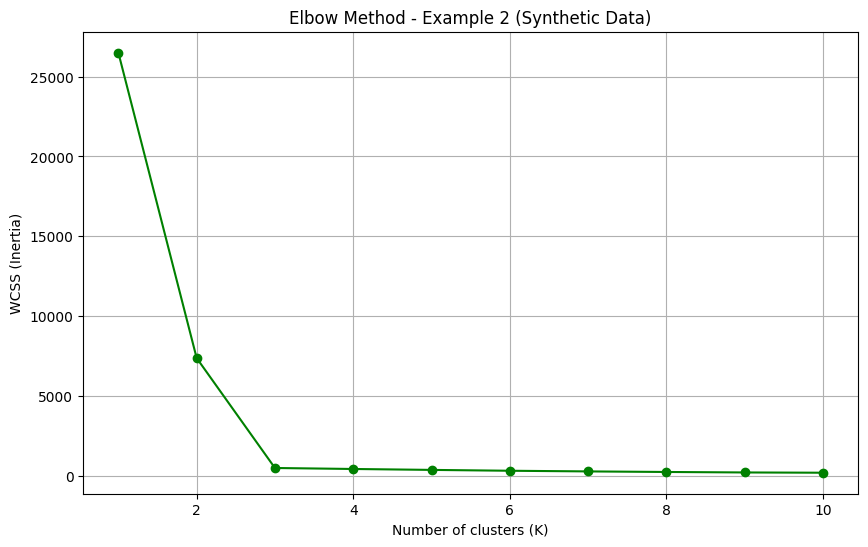

For this dataset, the 'elbow' point seems to be at K=3.


In [3]:
# Generate another synthetic data set
X2, y2 = make_blobs(n_samples=400, centers=3, cluster_std=0.8, random_state=42)

wcss_2 = []
for i in range(1, 11):
    kmeans_2 = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_2.fit(X2)
    wcss_2.append(kmeans_2.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_2, marker='o', color='green')
plt.title('Elbow Method - Example 2 (Synthetic Data)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()
print("For this dataset, the 'elbow' point seems to be at K=3.")

### 2. Silhouette Score

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. A score of 1 means clusters are dense and well-separated, 0 means overlapping clusters, and -1 means an object has been assigned to the wrong cluster.

#### Example 1: Synthetic Data

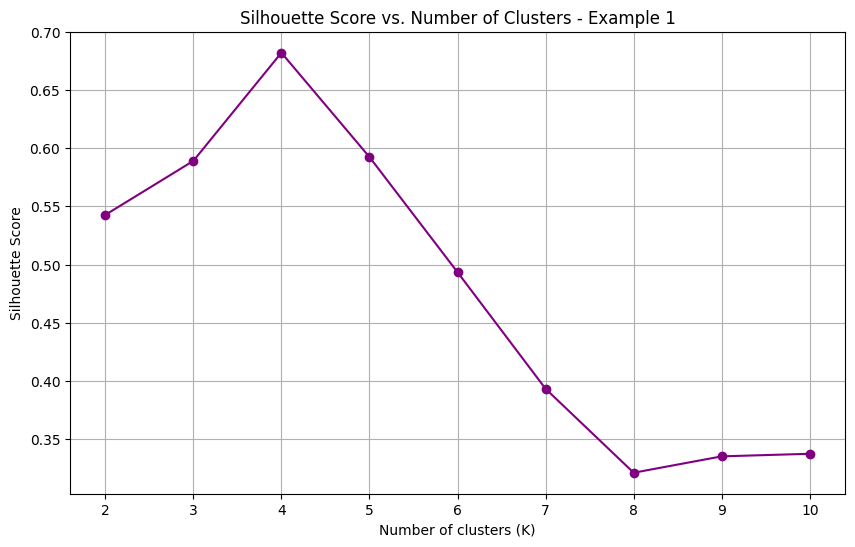

The optimal number of clusters based on Silhouette Score is: 4


In [4]:
# Using the first synthetic data set (X) from the Elbow Method

silhouette_scores = []
K_range = range(2, 11) # Silhouette score requires at least 2 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', color='purple')
plt.title('Silhouette Score vs. Number of Clusters - Example 1')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
print(f"The optimal number of clusters based on Silhouette Score is: {optimal_k_silhouette}")

#### Example 2: Another Synthetic Data Set

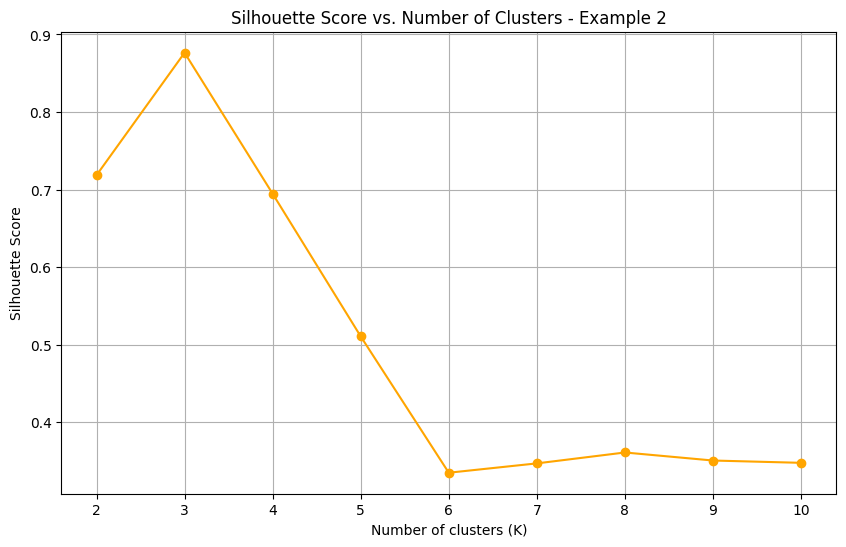

The optimal number of clusters based on Silhouette Score for the second dataset is: 3


In [5]:
# Using the second synthetic data set (X2) from the Elbow Method

silhouette_scores_2 = []
K_range_2 = range(2, 11)

for k in K_range_2:
    kmeans_2 = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels_2 = kmeans_2.fit_predict(X2)
    score_2 = silhouette_score(X2, cluster_labels_2)
    silhouette_scores_2.append(score_2)

plt.figure(figsize=(10, 6))
plt.plot(K_range_2, silhouette_scores_2, marker='o', color='orange')
plt.title('Silhouette Score vs. Number of Clusters - Example 2')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

optimal_k_silhouette_2 = K_range_2[np.argmax(silhouette_scores_2)]
print(f"The optimal number of clusters based on Silhouette Score for the second dataset is: {optimal_k_silhouette_2}")

### 3. Davies-Bouldin Index

The Davies-Bouldin Index is a metric that evaluates the ratio of the within-cluster scatter to the between-cluster separation. A lower Davies-Bouldin index indicates better clustering, meaning clusters are more compact and better separated from each other.

#### Example 1: Synthetic Data

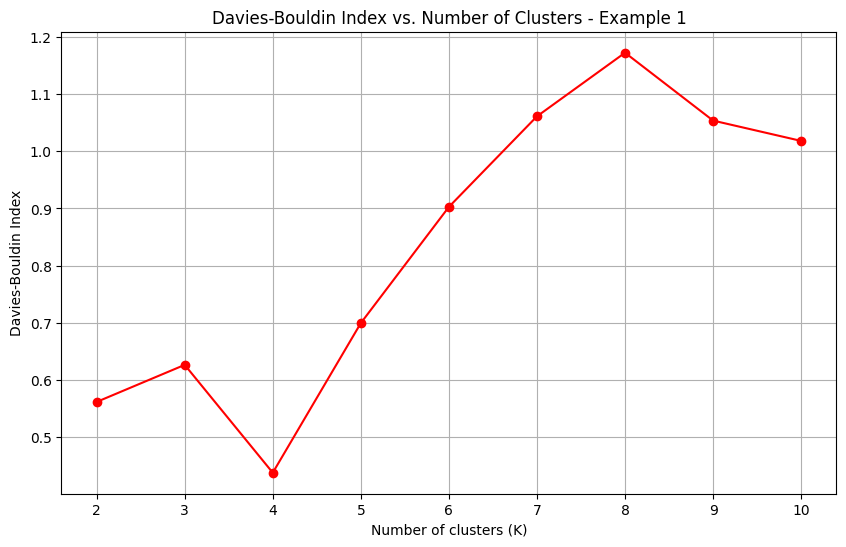

The optimal number of clusters based on Davies-Bouldin Index is: 4


In [6]:
# Using the first synthetic data set (X)

davies_bouldin_indices = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    # The Davies-Bouldin index is not defined for a single cluster
    if len(np.unique(cluster_labels)) > 1:
        score = davies_bouldin_score(X, cluster_labels)
        davies_bouldin_indices.append(score)
    else:
        davies_bouldin_indices.append(np.inf) # Assign infinity if only one cluster

plt.figure(figsize=(10, 6))
plt.plot(K_range, davies_bouldin_indices, marker='o', color='red')
plt.title('Davies-Bouldin Index vs. Number of Clusters - Example 1')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True)
plt.show()

optimal_k_db = K_range[np.argmin(davies_bouldin_indices)]
print(f"The optimal number of clusters based on Davies-Bouldin Index is: {optimal_k_db}")

#### Example 2: Another Synthetic Data Set

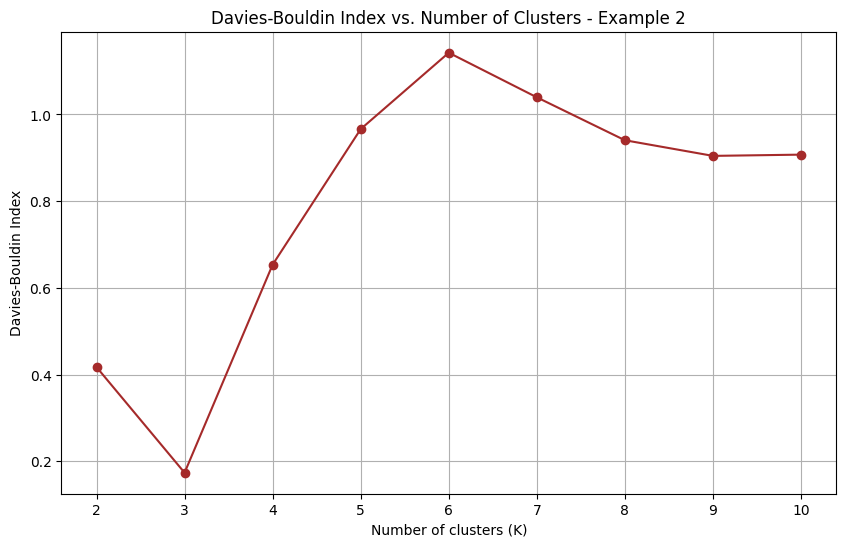

The optimal number of clusters based on Davies-Bouldin Index for the second dataset is: 3


In [7]:
# Using the second synthetic data set (X2)

davies_bouldin_indices_2 = []
K_range_2 = range(2, 11)

for k in K_range_2:
    kmeans_2 = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels_2 = kmeans_2.fit_predict(X2)
    if len(np.unique(cluster_labels_2)) > 1:
        score_2 = davies_bouldin_score(X2, cluster_labels_2)
        davies_bouldin_indices_2.append(score_2)
    else:
        davies_bouldin_indices_2.append(np.inf)

plt.figure(figsize=(10, 6))
plt.plot(K_range_2, davies_bouldin_indices_2, marker='o', color='brown')
plt.title('Davies-Bouldin Index vs. Number of Clusters - Example 2')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True)
plt.show()

optimal_k_db_2 = K_range_2[np.argmin(davies_bouldin_indices_2)]
print(f"The optimal number of clusters based on Davies-Bouldin Index for the second dataset is: {optimal_k_db_2}")

### 4. Calinski-Harabasz Index (Variance Ratio Criterion)

The Calinski-Harabasz Index (also known as the Variance Ratio Criterion) is a metric that calculates the ratio of the between-cluster variance to the within-cluster variance. A higher Calinski-Harabasz score relates to a model with better-defined clusters. It is generally faster to compute than the Silhouette Score.

#### Example 1: Synthetic Data

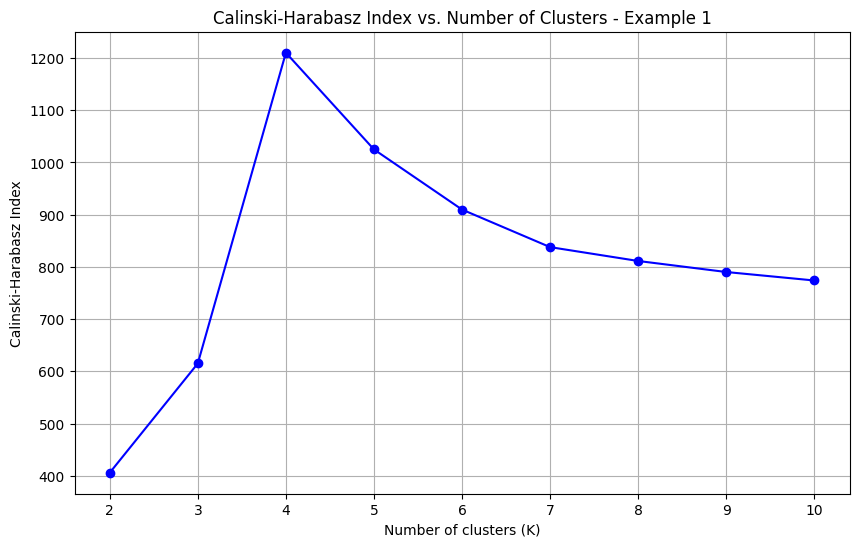

The optimal number of clusters based on Calinski-Harabasz Index is: 4


In [8]:
# Using the first synthetic data set (X)

calinski_harabasz_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    # The Calinski-Harabasz index is not defined for a single cluster
    if len(np.unique(cluster_labels)) > 1:
        score = calinski_harabasz_score(X, cluster_labels)
        calinski_harabasz_scores.append(score)
    else:
        calinski_harabasz_scores.append(0) # Assign 0 if only one cluster (lowest possible)

plt.figure(figsize=(10, 6))
plt.plot(K_range, calinski_harabasz_scores, marker='o', color='blue')
plt.title('Calinski-Harabasz Index vs. Number of Clusters - Example 1')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Calinski-Harabasz Index')
plt.grid(True)
plt.show()

optimal_k_ch = K_range[np.argmax(calinski_harabasz_scores)]
print(f"The optimal number of clusters based on Calinski-Harabasz Index is: {optimal_k_ch}")

#### Example 2: Another Synthetic Data Set

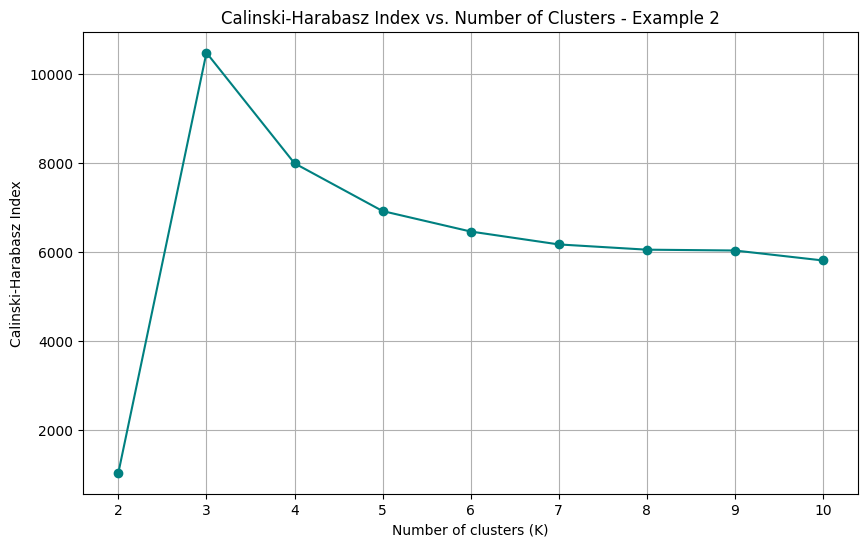

The optimal number of clusters based on Calinski-Harabasz Index for the second dataset is: 3


In [9]:
# Using the second synthetic data set (X2)

calinski_harabasz_scores_2 = []
K_range_2 = range(2, 11)

for k in K_range_2:
    kmeans_2 = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels_2 = kmeans_2.fit_predict(X2)
    if len(np.unique(cluster_labels_2)) > 1:
        score_2 = calinski_harabasz_score(X2, cluster_labels_2)
        calinski_harabasz_scores_2.append(score_2)
    else:
        calinski_harabasz_scores_2.append(0)

plt.figure(figsize=(10, 6))
plt.plot(K_range_2, calinski_harabasz_scores_2, marker='o', color='teal')
plt.title('Calinski-Harabasz Index vs. Number of Clusters - Example 2')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Calinski-Harabasz Index')
plt.grid(True)
plt.show()

optimal_k_ch_2 = K_range_2[np.argmax(calinski_harabasz_scores_2)]
print(f"The optimal number of clusters based on Calinski-Harabasz Index for the second dataset is: {optimal_k_ch_2}")